# Is there a relationship between accessibility signal and distance to the TSS?

## opening ATAC data and filtering with the p value

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

This filtering approach is further explained in the notebook containing the ATAC-seq data filtering

In [22]:
from pathlib import Path
ATAC_path = Path('data') / 'ImmGenATAC18_AllOCRsInfo.csv'
ATAC_data = pd.read_csv(ATAC_path)
ATAC_pfiltered = ATAC_data[ATAC_data['_-log10_bestPvalue'] > -np.log10(0.05)]
ATAC_pfiltered

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
2,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,2.36,0.10,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
3,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.41,0.10,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
4,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.41,0.10,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50
5,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,2.36,1.64,...,1.34,0.29,0.23,0.89,0.11,0.53,1.40,0.90,2.87,9.09
6,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.41,0.10,...,0.87,1.93,0.59,0.11,1.39,2.58,0.75,2.30,2.34,11.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512588,ImmGenATAC1219.peak_512589,chrY,90811728,0.00,2.33,1.0,NaN,Erdr1,0.41,7.41,...,4.98,4.47,2.83,4.93,4.92,5.13,9.13,2.21,6.53,6.11
512589,ImmGenATAC1219.peak_512590,chrY,90812084,0.00,3.12,1.0,NaN,Erdr1,2.36,8.79,...,4.03,4.07,5.87,5.36,3.99,7.12,3.57,2.64,5.59,3.64
512590,ImmGenATAC1219.peak_512591,chrY,90812450,0.00,3.99,1.0,NaN,Erdr1,4.37,8.79,...,3.81,3.34,4.27,6.73,5.53,7.21,5.96,5.17,6.53,6.11
512591,ImmGenATAC1219.peak_512592,chrY,90812906,0.00,3.21,1.0,NaN,Erdr1,0.41,7.41,...,4.28,5.55,4.15,6.88,7.16,6.21,8.75,6.83,8.14,4.64


### creating a file for the filtered ATACseq data

for not having to apply the filtering every time

In [23]:
ATAC_pfiltered.to_csv('data/ATAC_pfiltered.csv', index=False, header=True)
ATAC_pfiltered_check = pd.read_csv('data/ATAC_pfiltered.csv')
ATAC_pfiltered_check

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,2.36,0.10,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
1,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.41,0.10,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
2,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.41,0.10,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50
3,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,2.36,1.64,...,1.34,0.29,0.23,0.89,0.11,0.53,1.40,0.90,2.87,9.09
4,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.41,0.10,...,0.87,1.93,0.59,0.11,1.39,2.58,0.75,2.30,2.34,11.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362325,ImmGenATAC1219.peak_512589,chrY,90811728,0.00,2.33,1.0,NaN,Erdr1,0.41,7.41,...,4.98,4.47,2.83,4.93,4.92,5.13,9.13,2.21,6.53,6.11
362326,ImmGenATAC1219.peak_512590,chrY,90812084,0.00,3.12,1.0,NaN,Erdr1,2.36,8.79,...,4.03,4.07,5.87,5.36,3.99,7.12,3.57,2.64,5.59,3.64
362327,ImmGenATAC1219.peak_512591,chrY,90812450,0.00,3.99,1.0,NaN,Erdr1,4.37,8.79,...,3.81,3.34,4.27,6.73,5.53,7.21,5.96,5.17,6.53,6.11
362328,ImmGenATAC1219.peak_512592,chrY,90812906,0.00,3.21,1.0,NaN,Erdr1,0.41,7.41,...,4.28,5.55,4.15,6.88,7.16,6.21,8.75,6.83,8.14,4.64


## plot accessibility signal over distance to TSS

### open "Gene annotations"

In [24]:
cols = [
    "gene_name",
    "transcript_name",
    "chrom",
    "strand",
    "txStart",
    "txEnd",
    "cdsStart",
    "cdsEnd",
    "exonCount",
    "exonStarts",
    "exonEnds"
]

gene_annotations_path = Path('data') / 'Gene annotations.txt'
gene_annotations = pd.read_csv(gene_annotations_path, sep="\t", names=cols)
gene_annotations.to_csv('data/gene_annotations.csv', index=False)
gene_annotations_check = pd.read_csv('data/gene_annotations.csv')
gene_annotations_check

,gene_name,transcript_name,chrom,strand,txStart,txEnd,cdsStart,cdsEnd,exonCount,exonStarts,exonEnds
0,Wdsub1,NM_001159636,chr2,-,59855193,59882606,59855270,59878527,11,"59855193,59858609,59861560,59862619,59862816,5...","59855275,59858750,59861737,59862726,59862857,5..."
1,Rbm18,NM_001159635,chr2,-,36116078,36136704,36117814,36134247,6,"36116078,36120812,36122851,36127214,36134134,3...","36117974,36120898,36122938,36127251,36134263,3..."
2,Prrc2b,NM_001159634,chr2,+,32151147,32234537,32182511,32230742,32,"32151147,32182457,32183122,32185344,32187480,3...","32151291,32182626,32183300,32185447,32187553,3..."
3,Ildr2,NM_001164528,chr1,+,166254138,166316832,166254375,166310795,10,"166254138,166269304,166270498,166291415,166294...","166254466,166269637,166270618,166291472,166294..."
4,Perm1,NM_172417,chr4,+,156215926,156221307,156217000,156220222,4,"156215926,156216716,156219740,156220109,","156215975,156219185,156219866,156221307,"
...,...,...,...,...,...,...,...,...,...,...,...
47377,Kcnc3,NR_169735,chr7,+,44590451,44604751,44604751,44604751,6,"44590451,44595160,44598380,44598805,44600673,4...","44591758,44596268,44598575,44598933,44600928,4..."
47378,Kcnc3,NR_169736,chr7,+,44590451,44604751,44604751,44604751,6,"44590451,44595160,44598380,44598805,44600868,4...","44591758,44596268,44598575,44598933,44600928,4..."
47379,Kcnc3,NR_169737,chr7,+,44590451,44604751,44604751,44604751,6,"44590451,44595160,44598383,44598805,44600868,4...","44591758,44596268,44598575,44598933,44600928,4..."
47380,Ttn,NM_001385708,chr2,-,76703980,76982546,76705030,76980182,349,"76703980,76705669,76706439,76706696,76708158,7...","76705329,76705972,76706593,76707388,76708315,7..."


I also created a .csv file so it is easier to open, when needed again

### Match ATAC genes to gene annotations and compute distance to TSS

In [25]:
gene_and_TSS = gene_annotations[["gene_name", "txStart"]].copy()


ATAC_merged = ATAC_pfiltered.merge(
    gene_and_TSS,
    left_on="genes.within.100Kb",
    right_on="gene_name",
    how="right"
)


ATAC_merged["distance_to_tss"] = abs(ATAC_merged["Summit"] - ATAC_merged["txStart"])


keep_cols = list(ATAC_pfiltered.columns[8:]) + ["distance_to_tss"]
ATAC_dis_TSS = ATAC_merged[keep_cols].copy()

ATAC_dis_TSS

,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,preB.FrD.BM,B.FrE.BM,B1b.PC,...,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th,distance_to_tss
0,0.41,10.26,2.69,3.93,0.11,1.71,1.30,1.49,0.78,0.14,...,0.97,1.79,1.37,1.32,1.94,1.52,0.57,2.17,0.94,69437.0
1,0.41,1.64,0.90,0.83,0.11,0.34,0.98,0.13,0.57,2.22,...,1.83,1.20,0.89,1.39,0.14,0.88,0.11,2.63,1.03,55179.0
2,0.41,0.10,3.52,2.15,1.21,1.36,0.11,1.69,0.78,0.60,...,1.41,0.23,1.37,1.75,0.92,1.37,0.57,1.04,3.00,54526.0
3,0.41,21.83,13.69,10.15,5.94,2.78,3.21,1.17,2.67,5.85,...,2.18,2.50,0.89,1.75,0.50,0.75,1.16,1.23,1.26,54139.0
4,2.36,7.41,0.90,5.27,1.37,0.99,0.42,3.69,2.25,2.00,...,9.48,0.23,5.00,16.82,1.10,1.83,3.43,5.38,0.94,52303.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221768,2.36,7.41,3.52,2.15,1.88,2.29,2.20,1.85,1.32,3.82,...,0.54,0.66,1.79,0.11,5.06,1.83,4.34,5.80,2.24,266968.0
221769,2.36,8.79,1.85,8.49,5.76,4.53,6.47,2.37,2.67,3.86,...,2.54,2.16,1.39,2.07,4.38,2.87,9.00,18.22,1.86,276407.0
221770,0.41,1.64,0.90,4.34,6.94,4.29,1.29,0.49,0.32,0.60,...,0.36,1.89,1.39,0.95,2.58,1.83,2.59,4.40,0.11,300528.0
221771,4.37,2.57,3.52,5.80,6.56,7.64,3.91,1.85,1.32,3.25,...,1.38,3.47,1.76,1.34,9.44,0.98,2.59,10.39,3.37,358081.0


### creating a scatter plot connecting accessibility score to distance from TSS

/Users/tilmannstieglitz/Library/Mobile Documents/com~apple~CloudDocs/4.Semester/Bioinformatik/topic04_team03/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


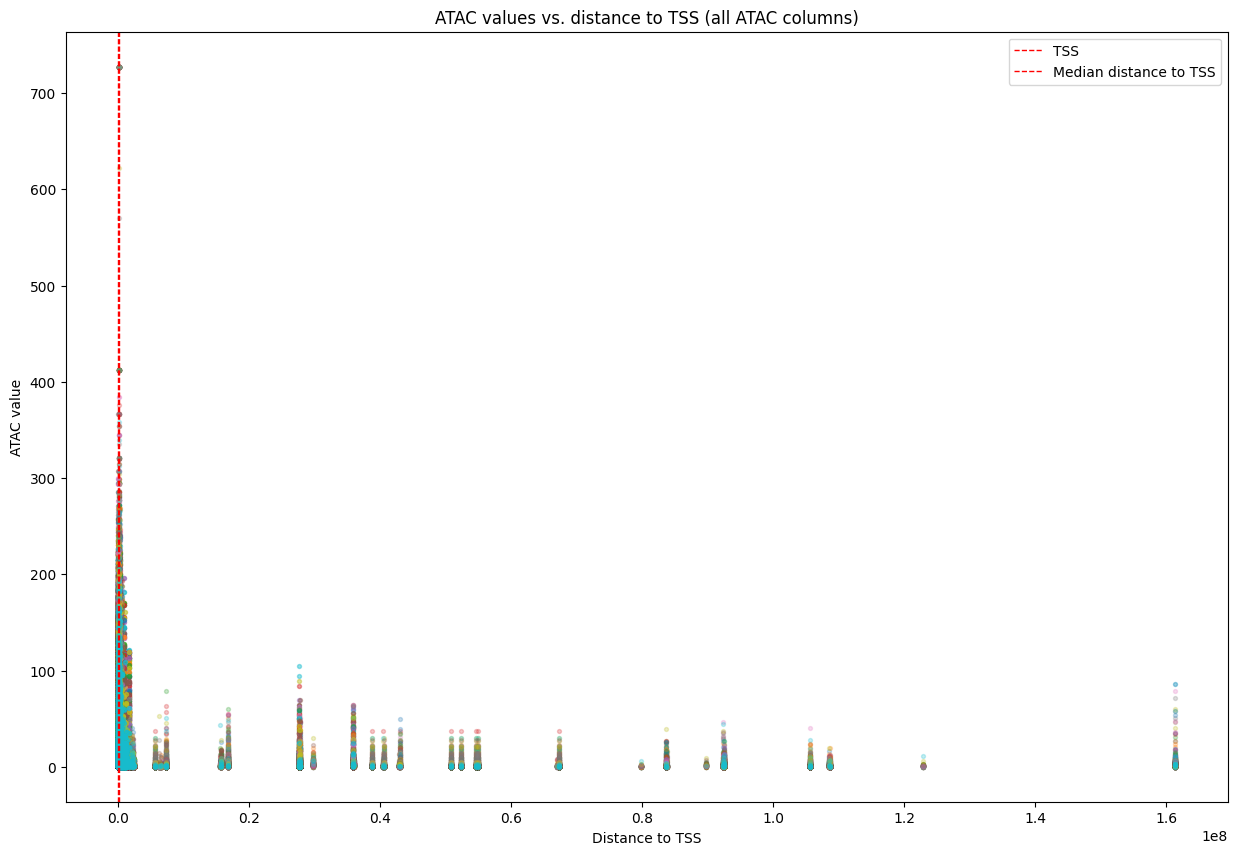

In [26]:
plot_data = ATAC_dis_TSS.iloc[:, :-1]
x = ATAC_dis_TSS['distance_to_tss']

plt.figure(figsize=(15, 10))
for col in plot_data.columns:
    plt.scatter(x, plot_data[col], alpha=0.25, s=8)
plt.xlabel('Distance to TSS')
plt.ylabel('ATAC value')
plt.title('ATAC values vs. distance to TSS (all ATAC columns)')
plt.axvline(0, color='red', linestyle='--', linewidth=1, label='TSS')
plt.axvline(ATAC_dis_TSS['distance_to_tss'].median(), color='red', linestyle='--', linewidth=1, label='Median distance to TSS')
plt.legend()
plt.show()


There seems to be a problem with this plot. Distance to TSS should not be greater than 100.000.
Since the median and the mean are very low compared to the highest values one possible solution coul be to just remove very high values.

Remove the top 1 % of values

In [27]:
ATAC_dis_TSS_filtered = ATAC_dis_TSS.drop(ATAC_dis_TSS[ATAC_dis_TSS['distance_to_tss'] > ATAC_dis_TSS['distance_to_tss'].quantile(0.99)].index)
ATAC_dis_TSS_filtered

,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,preB.FrD.BM,B.FrE.BM,B1b.PC,...,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th,distance_to_tss
0,0.41,10.26,2.69,3.93,0.11,1.71,1.30,1.49,0.78,0.14,...,0.97,1.79,1.37,1.32,1.94,1.52,0.57,2.17,0.94,69437.0
1,0.41,1.64,0.90,0.83,0.11,0.34,0.98,0.13,0.57,2.22,...,1.83,1.20,0.89,1.39,0.14,0.88,0.11,2.63,1.03,55179.0
2,0.41,0.10,3.52,2.15,1.21,1.36,0.11,1.69,0.78,0.60,...,1.41,0.23,1.37,1.75,0.92,1.37,0.57,1.04,3.00,54526.0
3,0.41,21.83,13.69,10.15,5.94,2.78,3.21,1.17,2.67,5.85,...,2.18,2.50,0.89,1.75,0.50,0.75,1.16,1.23,1.26,54139.0
4,2.36,7.41,0.90,5.27,1.37,0.99,0.42,3.69,2.25,2.00,...,9.48,0.23,5.00,16.82,1.10,1.83,3.43,5.38,0.94,52303.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221768,2.36,7.41,3.52,2.15,1.88,2.29,2.20,1.85,1.32,3.82,...,0.54,0.66,1.79,0.11,5.06,1.83,4.34,5.80,2.24,266968.0
221769,2.36,8.79,1.85,8.49,5.76,4.53,6.47,2.37,2.67,3.86,...,2.54,2.16,1.39,2.07,4.38,2.87,9.00,18.22,1.86,276407.0
221770,0.41,1.64,0.90,4.34,6.94,4.29,1.29,0.49,0.32,0.60,...,0.36,1.89,1.39,0.95,2.58,1.83,2.59,4.40,0.11,300528.0
221771,4.37,2.57,3.52,5.80,6.56,7.64,3.91,1.85,1.32,3.25,...,1.38,3.47,1.76,1.34,9.44,0.98,2.59,10.39,3.37,358081.0


/Users/tilmannstieglitz/Library/Mobile Documents/com~apple~CloudDocs/4.Semester/Bioinformatik/topic04_team03/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


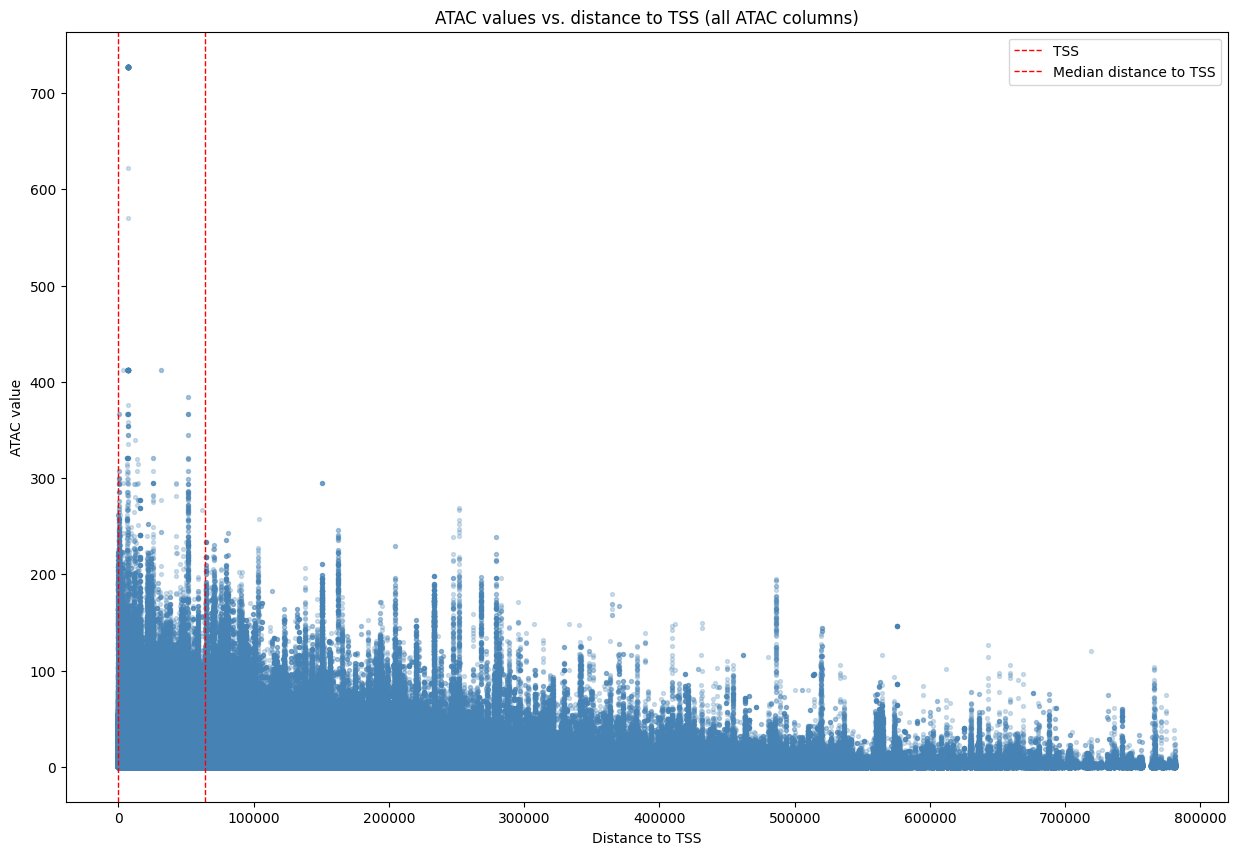

In [28]:
plot_data_filtered = ATAC_dis_TSS_filtered.iloc[:, :-1]
x = ATAC_dis_TSS_filtered['distance_to_tss']

plt.figure(figsize=(15, 10))
for col in plot_data_filtered.columns:
    plt.scatter(x, plot_data_filtered[col], alpha=0.25, s=8, color='steelblue')
plt.xlabel('Distance to TSS')
plt.ylabel('ATAC value')
plt.title('ATAC values vs. distance to TSS (all ATAC columns)')
plt.axvline(0, color='red', linestyle='--', linewidth=1, label='TSS')
plt.axvline(ATAC_dis_TSS_filtered['distance_to_tss'].median(), color='red', linestyle='--', linewidth=1, label='Median distance to TSS')
plt.legend()
plt.show()

After removing the top 1% furthest ATAC peaks there are still some with distances over 100 kb.

same plot but with a max distance of 100.000

/Users/tilmannstieglitz/Library/Mobile Documents/com~apple~CloudDocs/4.Semester/Bioinformatik/topic04_team03/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


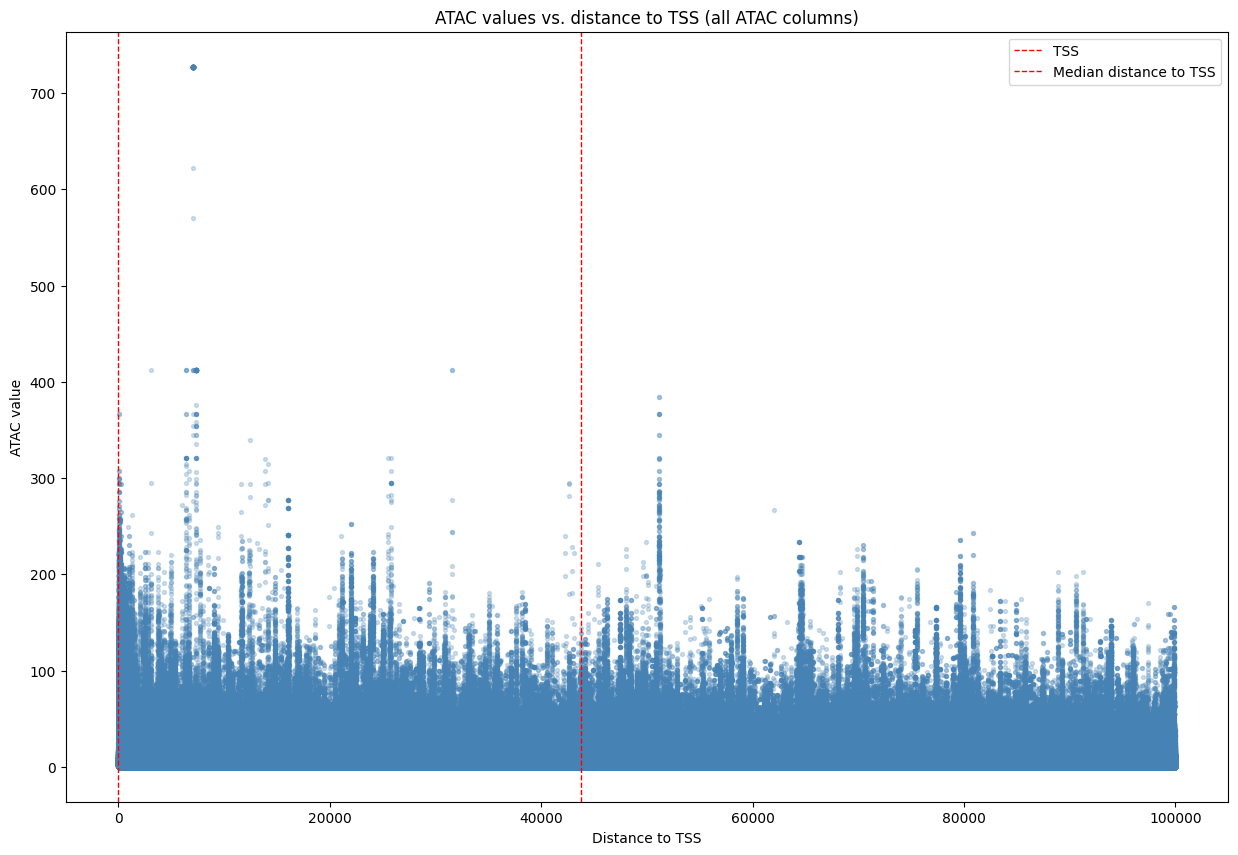

In [29]:
ATAC_dis_TSS_100kb = ATAC_dis_TSS.drop(ATAC_dis_TSS[ATAC_dis_TSS['distance_to_tss'] > 100000].index)

plot_data_100kb = ATAC_dis_TSS_100kb.iloc[:, :-1]
x = ATAC_dis_TSS_100kb['distance_to_tss']

plt.figure(figsize=(15, 10))
for col in plot_data_100kb.columns:
    plt.scatter(x, plot_data_100kb[col], alpha=0.25, s=8, color='steelblue')
plt.xlabel('Distance to TSS')
plt.ylabel('ATAC value')
plt.title('ATAC values vs. distance to TSS (all ATAC columns)')
plt.axvline(0, color='red', linestyle='--', linewidth=1, label='TSS')
plt.axvline(ATAC_dis_TSS_100kb['distance_to_tss'].median(), color='red', linestyle='--', linewidth=1, label='Median distance to TSS')
plt.legend()
plt.show()

## creating a histogram of active OCRs in relation to distance from TSS

In [30]:
ATAC_value_median = ATAC_dis_TSS_filtered.iloc[:, :-1].median(axis=None)

the median expression was chosen as arbitrary threshold to define what ATAC peaks are active

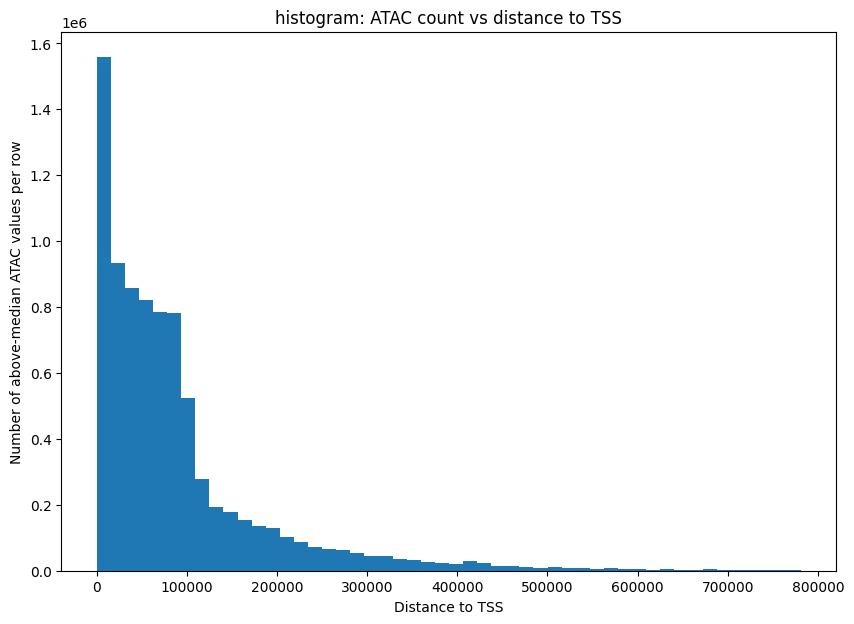

In [31]:
atac_values = ATAC_dis_TSS_filtered.iloc[:, :-1]

active_atac_counts = (atac_values.fillna(0) > ATAC_value_median).sum(axis=1)

distances = ATAC_dis_TSS_filtered['distance_to_tss']

plt.figure(figsize=(10, 7))
plt.hist(distances, bins=50, weights=active_atac_counts)
plt.xlabel('Distance to TSS')
plt.ylabel('Number of above-median ATAC values per row')
plt.title('histogram: ATAC count vs distance to TSS')
plt.show()

the drop of at 100kb could be due to the fact that there should not be any values above 100kb in the first place

creating the same histogram with only those distances of up to 100kb

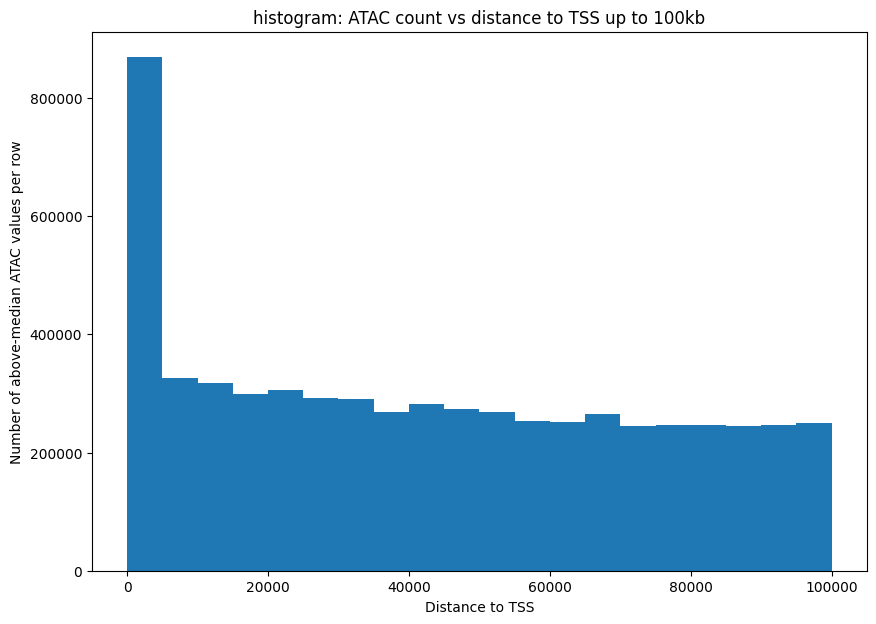

In [32]:
atac_values = ATAC_dis_TSS_100kb.iloc[:, :-1]

active_atac_counts = (atac_values.fillna(0) > ATAC_value_median).sum(axis=1)

distances = ATAC_dis_TSS_100kb['distance_to_tss']

plt.figure(figsize=(10, 7))
plt.hist(distances, bins=20, weights=active_atac_counts)
plt.xlabel('Distance to TSS')
plt.ylabel('Number of above-median ATAC values per row')
plt.title('histogram: ATAC count vs distance to TSS up to 100kb')
plt.show()

### quantifying the relationship between accessibility score and distance to TSS

At first I want to test how significantly different the first bin is from the rest by using a one sample t-test.

868743.0
[326979. 318521. 298858. 305871. 293056. 290694. 268880. 281512. 273319.
 267938. 252651. 251437. 264833. 244517. 246562. 247221. 245689. 246791.
 250456.]
272409.7368421053
25772.76487596549


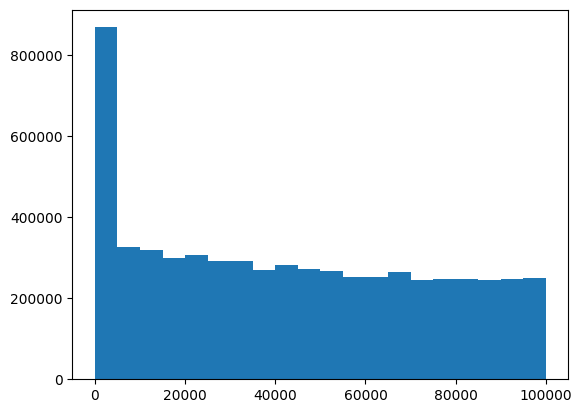

In [33]:
counts, bin_edges, patches = plt.hist(distances, bins=20, weights=active_atac_counts)
print(counts[0])
print(counts[1:])
print(counts[1:].mean())
print(counts[1:].std())

In [34]:
from scipy import stats

first_bin_count = counts[0]
other_bin_counts = counts[1:]

ttest_result = stats.ttest_1samp(other_bin_counts, popmean=first_bin_count)

print('First bin count:', first_bin_count)
print('Other bins counts:', other_bin_counts)
print('Other bins mean:', other_bin_counts.mean())
print('One-sample t-test result:', ttest_result)
print('p-value:', ttest_result.pvalue)


First bin count: 868743.0
Other bins counts: [326979. 318521. 298858. 305871. 293056. 290694. 268880. 281512. 273319.
 267938. 252651. 251437. 264833. 244517. 246562. 247221. 245689. 246791.
 250456.]
Other bins mean: 272409.7368421053
One-sample t-test result: TtestResult(statistic=np.float64(-98.16671891946233), pvalue=np.float64(5.0517435202488577e-26), df=np.int64(18))
p-value: 5.0517435202488577e-26


difference is signifikant with a p-value of 5e-26

Now I want to perform linear regression to quantify how much the amount of active ATAC peaks decreases with distance from TSS.

Linear regression (excluding first bin):
Slope: -0.8761111631610177
R-squared: 0.8665737933579118
p-value: 7.456264490566113e-09


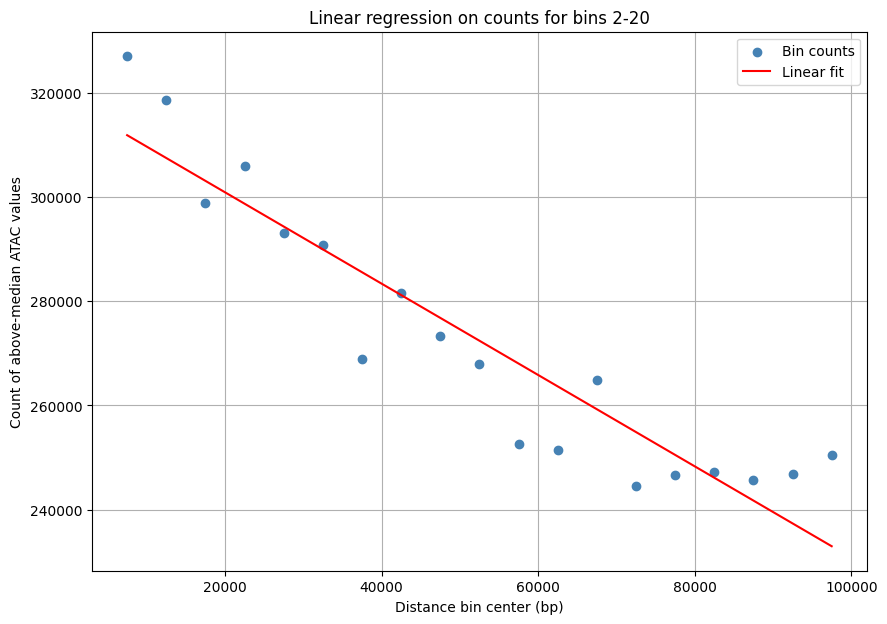

In [35]:
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
other_bin_centers = bin_centers[1:]
other_bin_counts = counts[1:]

linreg = stats.linregress(other_bin_centers, other_bin_counts)

print('Linear regression (excluding first bin):')
print('Slope:', linreg.slope)
print('R-squared:', linreg.rvalue ** 2)
print('p-value:', linreg.pvalue)

plt.figure(figsize=(10, 7))
plt.scatter(other_bin_centers, other_bin_counts, label='Bin counts', color='steelblue')
plt.plot(other_bin_centers, linreg.intercept + linreg.slope * other_bin_centers, color='red', label='Linear fit')
plt.xlabel('Distance bin center (bp)')
plt.ylabel('Count of above-median ATAC values')
plt.title('Linear regression on counts for bins 2-20')
plt.legend()
plt.grid(True)
plt.show()

The linear regression shows a clear decrease with a significant p-value

Now I check if the residuals are roughly distributed normally with a histogram and a qq-plot.

Residuals mean: -3.216739155744252e-11
Residuals std: 9672.130090442968


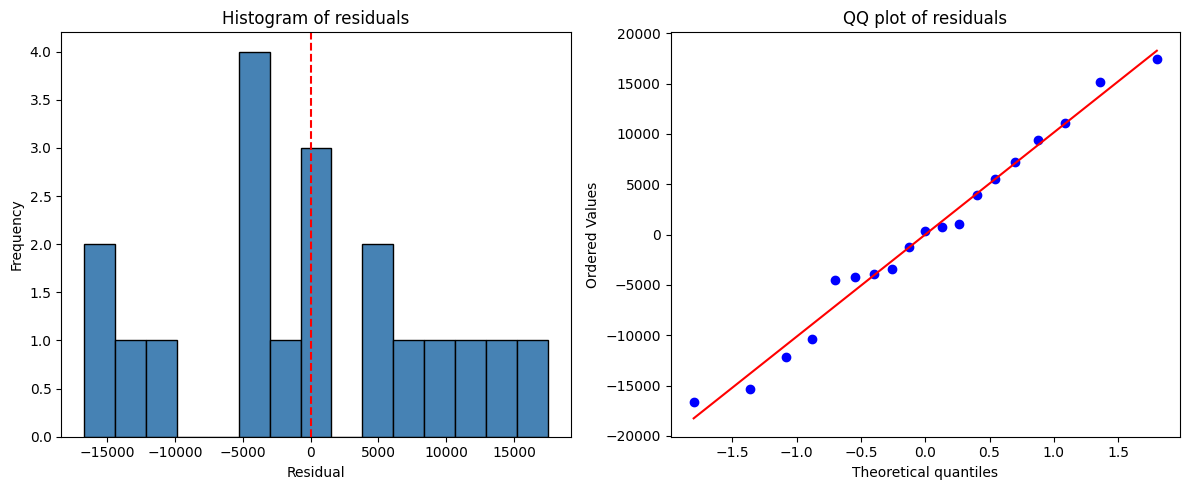

In [36]:
predicted_counts = linreg.intercept + linreg.slope * other_bin_centers
residuals = other_bin_counts - predicted_counts
print('Residuals mean:', np.mean(residuals))
print('Residuals std:', np.std(residuals, ddof=1))
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(residuals, bins=15, color='steelblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Histogram of residuals')
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist='norm', plot=plt)
plt.title('QQ plot of residuals')
plt.tight_layout()
plt.show()


## Looking at the OCRs with very high distances to the TSS

to see if very distant OCRs have a particular function, but these could also be just an error, because in theory they should not even be listed in the data as having a gene within 100 kb.

In [37]:

gene_and_TSS = gene_annotations[["gene_name", "txStart"]].copy()


ATAC_merged = ATAC_pfiltered.merge(
    gene_and_TSS,
    left_on="genes.within.100Kb",
    right_on="gene_name",
    how="right"
)


ATAC_merged["distance_to_tss"] = abs(ATAC_merged["Summit"] - ATAC_merged["txStart"])

In [38]:
ATAC_dis_TSS_highest_with_na = ATAC_merged.drop(ATAC_merged[ATAC_merged['distance_to_tss'] < ATAC_merged['distance_to_tss'].quantile(0.999)].index)
ATAC_dis_TSS_highest = ATAC_dis_TSS_highest_with_na.dropna(subset=["distance_to_tss"]).copy()
ATAC_dis_TSS_highest

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th,gene_name,txStart,distance_to_tss
12971,ImmGenATAC1219.peak_81404,chr11,75033130.0,0.81,6.62,1.0,NaN,Mir684-1,0.41,1.64,...,0.11,0.95,0.92,0.34,1.71,1.64,0.53,Mir684-1,36389910,38643220.0
12972,ImmGenATAC1219.peak_81405,chr11,75033878.0,0.98,1.42,NaN,NaN,Mir684-1,0.41,0.10,...,0.11,0.95,0.56,0.10,9.77,21.31,0.11,Mir684-1,36389910,38643968.0
12973,ImmGenATAC1219.peak_81408,chr11,75038564.0,0.34,2.22,1.0,NaN,Mir684-1,0.41,0.71,...,0.53,0.51,0.50,0.88,0.11,1.04,0.53,Mir684-1,36389910,38648654.0
12974,ImmGenATAC1219.peak_81410,chr11,75047054.0,0.77,4.58,1.0,NaN,Mir684-1,7.00,0.71,...,0.47,0.95,21.57,0.34,8.71,4.12,0.93,Mir684-1,36389910,38657144.0
12975,ImmGenATAC1219.peak_81411,chr11,75047362.0,0.98,4.58,1.0,NaN,Mir684-1,19.40,4.78,...,1.37,1.32,27.43,1.75,14.16,21.06,2.84,Mir684-1,36389910,38657452.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175791,ImmGenATAC1219.peak_511558,chrX,163301233.0,0.02,8.99,1.0,NaN,Bc1,26.12,27.07,...,10.66,7.03,0.14,2.83,0.53,3.39,0.11,Bc1,79697304,83603929.0
175792,ImmGenATAC1219.peak_511559,chrX,163301902.0,0.00,2.98,1.0,NaN,Bc1,2.36,0.71,...,0.95,2.90,0.53,2.58,0.95,0.64,0.50,Bc1,79697304,83604598.0
175793,ImmGenATAC1219.peak_511560,chrX,163302892.0,0.52,6.41,1.0,NaN,Bc1,0.41,0.71,...,7.41,8.55,6.07,5.84,0.11,1.23,1.86,Bc1,79697304,83605588.0
175794,ImmGenATAC1219.peak_511562,chrX,163310642.0,0.00,1.36,NaN,NaN,Bc1,2.36,0.10,...,3.80,0.51,0.85,0.50,2.30,1.64,3.96,Bc1,79697304,83613338.0


creating the same histogram as before, but now only with very distant OCRs

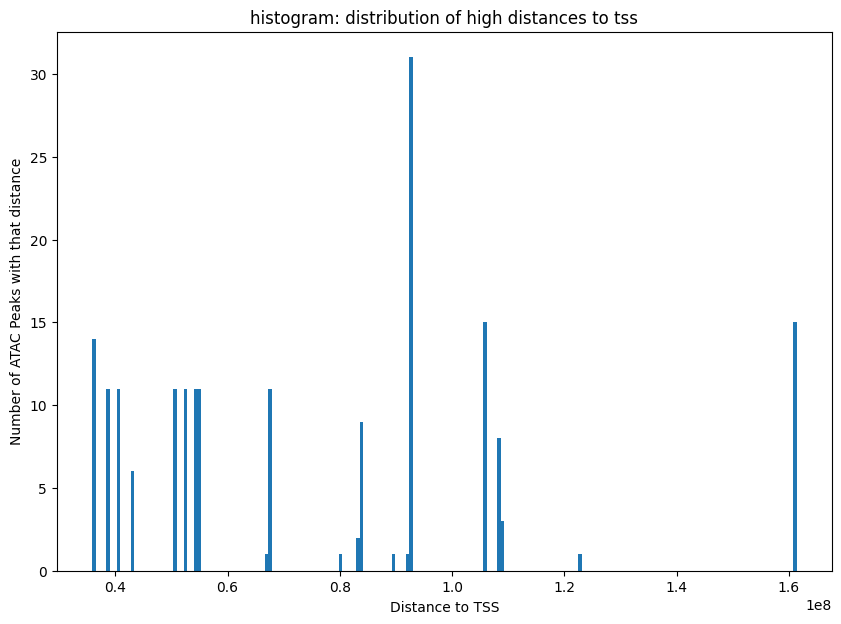

In [39]:
plt.figure(figsize=(10, 7))
plt.hist(ATAC_dis_TSS_highest["distance_to_tss"], bins=200,)
plt.xlabel('Distance to TSS')
plt.ylabel('Number of ATAC Peaks with that distance')
plt.title('histogram: distribution of high distances to tss')
plt.show()

now I want to see what genes are listed as within 100 kb (even though they seem to be further away)

In [40]:
ATAC_dis_TSS_highest_filtered = ATAC_dis_TSS_highest.drop(
    ATAC_dis_TSS_highest[
        ATAC_dis_TSS_highest[ATAC_dis_TSS_highest.columns[8:97]].max(axis=1) < 40
    ].index)
ATAC_dis_TSS_highest_filtered

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th,gene_name,txStart,distance_to_tss
30864,ImmGenATAC1219.peak_211811,chr17,30285850.0,0.04,22.06,1.0,NaN,Mir6412,0.41,0.10,...,1.39,0.98,0.14,1.29,0.52,0.64,0.93,Mir6412,122648338,92362488.0
69615,ImmGenATAC1219.peak_294133,chr2,166607073.0,0.00,26.11,1.0,NaN,Mir6364,0.41,1.64,...,1.37,0.95,2.98,1.29,0.14,1.05,3.29,Mir6364,5215788,161391285.0
69616,ImmGenATAC1219.peak_294135,chr2,166610442.0,0.02,49.07,1.0,NaN,Mir6364,0.41,0.71,...,3.72,1.82,1.61,2.29,1.33,0.64,2.73,Mir6364,5215788,161394654.0
73247,ImmGenATAC1219.peak_466992,chr8,96552748.0,0.04,9.26,1.0,NaN,Mir28c,12.99,6.07,...,0.47,2.53,1.85,0.26,0.90,1.64,0.94,Mir28c,53614204,42938544.0
106712,ImmGenATAC1219.peak_78614,chr11,63418217.0,0.12,13.20,1.0,NaN,Mir6354,2.36,6.07,...,0.53,0.51,1.47,0.26,2.59,0.11,0.53,Mir6354,169018973,105600756.0


most OCRs with high accessibility scores and large distances from the TSS seem to be conetcted to similar genes:

- "Mir" genes are coding for microRNA which has regulatory functions
- I could not find any "Bc1" genes on the X-chromosome
- some of the OCRs lie inside of other genes, therefore it is not likely that they are functionally connected to the gene from the data frame